In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/idataset1/zul_community_2017-sentences.csv


In [4]:
# ============================================================
# 🧠 isiZulu Text Classification using XLM-R Base (Full Pipeline)
# ============================================================

# ✅ 0. IMPORTS
import os
import pandas as pd
import numpy as np
import torch
import gc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from datasets import Dataset


In [5]:
# ============================================================
# ✅ 1. ENVIRONMENT SETUP
# ============================================================
os.environ["WANDB_DISABLED"] = "true"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"


In [6]:
# ============================================================
# ✅ 2. LOAD DATASET
# ============================================================
df = pd.read_csv("/kaggle/input/idataset1/zul_community_2017-sentences.csv")

# rename if necessary
if "sentence" in df.columns:
    df.rename(columns={"sentence": "text"}, inplace=True)

df.dropna(subset=["text"], inplace=True)
df.drop_duplicates(subset=["text"], inplace=True)

print("✅ Dataset loaded:", df.shape)
print(df.head())


✅ Dataset loaded: (142577, 1)
                                                text
0  1\t000 angeke kwakhelwe eqhazeni elibanjwa nge...
1  2\t10.10 Zama ukwenza izithiyo zokuthi kungant...
2  3\t10.12 Kwenze kuba umkhuba wakho ungalali ng...
3  4\t10.14 Thatha izithombe nezithupha zabo bonk...
4  5\t10.16 Izingane zakho kufanele zikwazi ukuph...


In [7]:
# ============================================================
# ✅ 3. LABEL CREATION (AUTOMATIC CATEGORIZATION)
# ============================================================
def categorize_text(t):
    t = t.lower()
    if any(word in t for word in ["intaba", "izwe", "idolobha", "umfula", "ulwandle", "inhlokodolobha"]):
        return "geography"
    elif any(word in t for word in ["galileo", "physics", "science", "experiment", "gravity"]):
        return "science"
    elif any(word in t for word in ["computer", "apple", "robot", "technology", "software"]):
        return "technology"
    elif any(word in t for word in ["owokuqala", "emlandweni", "unyaka", "revolution", "president"]):
        return "history"
    else:
        return "general"

df["label"] = df["text"].apply(categorize_text)
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])
label2id = {label: idx for idx, label in enumerate(le.classes_)}
id2label = {v: k for k, v in label2id.items()}
print("✅ Label mapping:", label2id)

✅ Label mapping: {'general': 0, 'geography': 1, 'history': 2, 'science': 3, 'technology': 4}


In [8]:
# ============================================================
# ✅ 4. TRAIN / TEST SPLIT
# ============================================================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"], df["label_encoded"], test_size=0.2, stratify=df["label_encoded"], random_state=42
)

In [9]:
# ============================================================
# ✅ 5. TOKENIZATION
# ============================================================
checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

train_dataset = Dataset.from_dict({"text": train_texts.tolist(), "label": train_labels.tolist()})
eval_dataset = Dataset.from_dict({"text": val_texts.tolist(), "label": val_labels.tolist()})

train_dataset = train_dataset.map(tokenize, batched=True)
eval_dataset = eval_dataset.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/114061 [00:00<?, ? examples/s]

Map:   0%|          | 0/28516 [00:00<?, ? examples/s]

In [10]:
# ============================================================
# ✅ 6. METRICS
# ============================================================
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


In [11]:
# ============================================================
# ✅ 7. MODEL INITIALIZATION
# ============================================================
num_labels = len(label2id)
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
# ============================================================
# ✅ 8. TRAINING ARGUMENTS
# ============================================================
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    logging_dir="./logs",
    save_total_limit=2,
    report_to="none"
)

In [13]:
# ============================================================
# ✅ 9. TRAINER
# ============================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


/tmp/ipykernel_35/2452886231.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [14]:
# ============================================================
# ✅ 10. TRAINING
# ============================================================
print("🚀 Training started...")
trainer.train()

🚀 Training started...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.179800,0.150591,0.991233,0.393839,0.383639,0.388555
2,0.165200,0.147652,0.991268,0.392986,0.384721,0.388726
3,0.150300,0.120824,0.992145,0.390294,0.388557,0.389412
4,0.105000,0.108961,0.992916,0.619560,0.567251,0.518407
5,0.130400,0.105654,0.993547,0.883881,0.568667,0.592034
6,0.105700,0.103960,0.993828,0.923992,0.659812,0.726965


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

TrainOutput(global_step=42774, training_loss=0.16054789425921306, metrics={'train_runtime': 21882.034, 'train_samples_per_second': 31.275, 'train_steps_per_second': 1.955, 'total_flos': 4.501727767137946e+16, 'train_loss': 0.16054789425921306, 'epoch': 6.0})

In [16]:

# ✅ 11. EVALUATION
# ============================================================
results = trainer.evaluate()
print("\n✅ Final Evaluation Results:", results)

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



✅ Final Evaluation Results: {'eval_loss': 0.1039598137140274, 'eval_accuracy': 0.9938280263711601, 'eval_precision': 0.9239917461621076, 'eval_recall': 0.6598124524301614, 'eval_f1': 0.726965036644828, 'eval_runtime': 252.1631, 'eval_samples_per_second': 113.086, 'eval_steps_per_second': 7.071, 'epoch': 6.0}


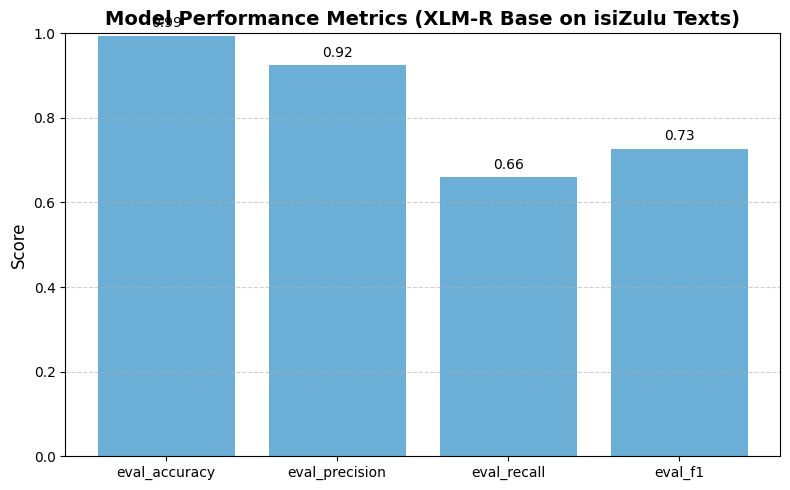


Generating confusion matrix...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


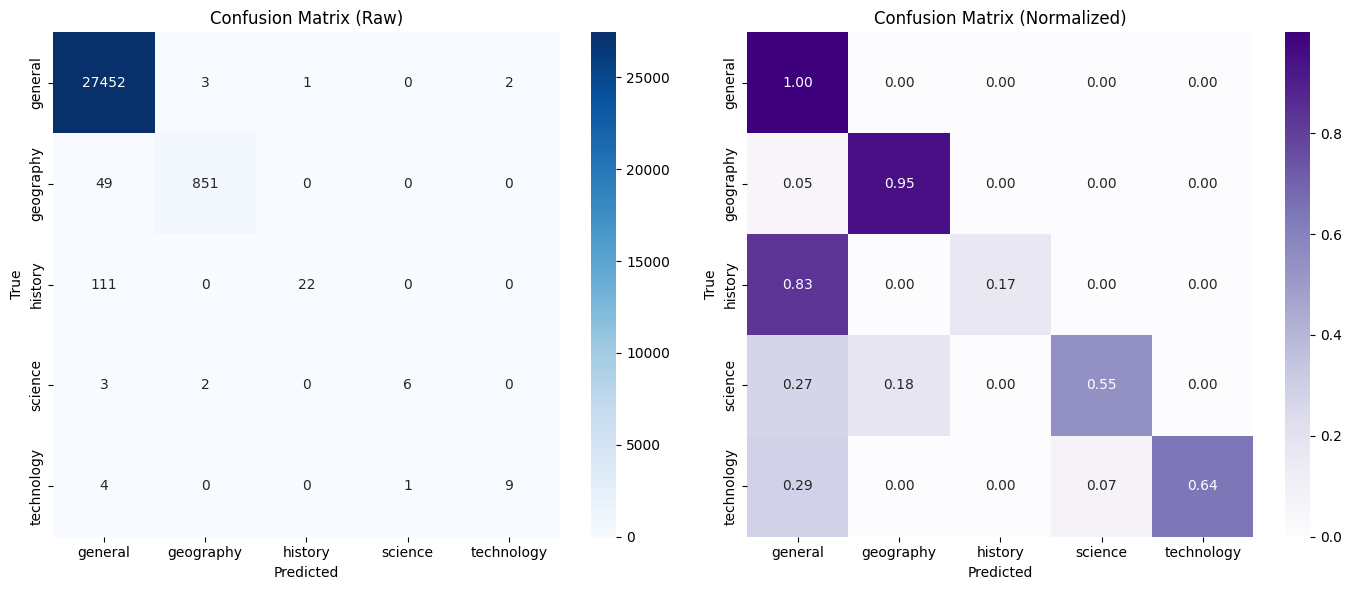

✅ Visualizations displayed and saved: metric_results.png and confusion_matrices.png


In [19]:
# ============================================================
# ✅ 12. VISUALIZATIONS (Show + Save)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- Bar Chart for Metrics ---
metrics_to_plot = ["eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]
values = [results[m] for m in metrics_to_plot]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics_to_plot, values, color="#6BAED6")
plt.ylim(0,1)
plt.title("Model Performance Metrics (XLM-R Base on isiZulu Texts)", fontsize=14, fontweight="bold")
plt.ylabel("Score", fontsize=12)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{bar.get_height():.2f}",
             ha="center", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# ✅ Display and Save
plt.show()
plt.savefig("metric_results.png", dpi=300)
plt.close()

# --- Confusion Matrix ---
print("\nGenerating confusion matrix...")

predictions = trainer.predict(eval_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)
labels = list(id2label.values())

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1)[:, None]

fig, ax = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title("Confusion Matrix (Raw)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Purples", xticklabels=labels, yticklabels=labels, ax=ax[1])
ax[1].set_title("Confusion Matrix (Normalized)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")

plt.tight_layout()

# ✅ Display and Save
plt.show()
plt.savefig("confusion_matrices.png", dpi=300)
plt.close()

print("✅ Visualizations displayed and saved: metric_results.png and confusion_matrices.png")


In [20]:
# ✅ 13. SAVE MODEL
# ============================================================
trainer.save_model("./xlmr_zulu_final")
tokenizer.save_pretrained("./xlmr_zulu_final")

print("\n✅ Model and tokenizer saved successfully.")


✅ Model and tokenizer saved successfully.


In [21]:
# ============================================================
# ✅ 14. CLEAN GPU MEMORY
# ============================================================
torch.cuda.empty_cache()
gc.collect()
print("\n🧹 GPU memory cleaned. Experiment completed successfully.")


🧹 GPU memory cleaned. Experiment completed successfully.
